In [1]:
IMG_SIZE = 128
CLASS_NAMES = ['normal', 'benign', 'malignant']
LABEL_MAP = {'normal': 0, 'benign': 1, 'malignant': 2}
DATA_PATH = 'data'

In [3]:
# src/data_loader.py
import os
import cv2
import numpy as np

def load_data(base_path):
    X, Y_class, Y_mask = [], [], []
    for label_name in LABEL_MAP:
        folder = os.path.join(base_path, label_name)
        for file in os.listdir(folder):
            if '_mask' in file:
                continue
            img_path = os.path.join(folder, file)
            mask_path = img_path.replace('.png', '_mask.png')

            if not os.path.exists(mask_path):
                continue

            image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE)) / 255.0
            mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE)) / 255.0

            image = np.expand_dims(image, axis=-1)
            mask = np.expand_dims(mask, axis=-1)

            X.append(image)
            Y_class.append(LABEL_MAP[label_name])
            Y_mask.append(mask)

    return np.array(X), np.array(Y_class), np.array(Y_mask)

In [4]:
# src/model.py
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, UpSampling2D

def build_model(img_size):
    inputs = Input(shape=(img_size, img_size, 1))

    # Shared encoder
    x = Conv2D(32, 3, activation='relu', padding='same')(inputs)
    x = MaxPooling2D(2)(x)
    x = Conv2D(64, 3, activation='relu', padding='same')(x)
    x = MaxPooling2D(2)(x)
    x = Conv2D(128, 3, activation='relu', padding='same')(x)
    x = MaxPooling2D(2)(x)

    # Segmentation branch
    seg = UpSampling2D(2)(x)
    seg = Conv2D(64, 3, activation='relu', padding='same')(seg)
    seg = UpSampling2D(2)(seg)
    seg = Conv2D(32, 3, activation='relu', padding='same')(seg)
    seg = UpSampling2D(2)(seg)
    seg_output = Conv2D(1, 1, activation='sigmoid', name='segmentation')(seg)

    # Classification branch
    cls = Flatten()(x)
    cls = Dense(128, activation='relu')(cls)
    cls = Dropout(0.5)(cls)
    cls_output = Dense(3, activation='softmax', name='classification')(cls)

    model = Model(inputs=inputs, outputs=[cls_output, seg_output])
    return model


In [6]:
# src/train.py
import tensorflow as tf
from sklearn.model_selection import train_test_split
# from src.config import IMG_SIZE
# from src.data_loader import load_data
# from src.model import build_model

def train_model():
    X, y_class, y_mask = load_data("data")
    y_class = tf.keras.utils.to_categorical(y_class, 3)

    X_train, X_test, y_class_train, y_class_test, y_mask_train, y_mask_test = train_test_split(
        X, y_class, y_mask, test_size=0.2, random_state=42
    )

    model = build_model(IMG_SIZE)
    model.compile(optimizer='adam',
                  loss={'classification': 'categorical_crossentropy', 'segmentation': 'binary_crossentropy'},
                  metrics={'classification': 'accuracy', 'segmentation': 'accuracy'})

    model.fit(X_train, {'classification': y_class_train, 'segmentation': y_mask_train},
              validation_data=(X_test, {'classification': y_class_test, 'segmentation': y_mask_test}),
              epochs=20, batch_size=16)

    model.save("ultrasound_model.h5")


In [7]:
# src/predict.py
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
# from src.config import IMG_SIZE, CLASS_NAMES

def predict(image_path):
    model = load_model("ultrasound_model.h5")

    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    image_resized = cv2.resize(image, (IMG_SIZE, IMG_SIZE)) / 255.0
    input_img = np.expand_dims(np.expand_dims(image_resized, axis=-1), axis=0)

    class_pred, mask_pred = model.predict(input_img)
    class_label = CLASS_NAMES[np.argmax(class_pred)]

    print("Predicted Class:", class_label)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Input Image")
    plt.imshow(image_resized, cmap='gray')

    plt.subplot(1, 2, 2)
    plt.title("Predicted Mask")
    plt.imshow(mask_pred[0, :, :, 0], cmap='gray')
    plt.show()


In [8]:
train_model()

Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 191ms/step - classification_accuracy: 0.5157 - classification_loss: 1.0746 - loss: 1.5709 - segmentation_accuracy: 0.9182 - segmentation_loss: 0.4963 - val_classification_accuracy: 0.5256 - val_classification_loss: 0.9802 - val_loss: 1.2858 - val_segmentation_accuracy: 0.9198 - val_segmentation_loss: 0.2997
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 169ms/step - classification_accuracy: 0.5750 - classification_loss: 0.9665 - loss: 1.2579 - segmentation_accuracy: 0.9164 - segmentation_loss: 0.2914 - val_classification_accuracy: 0.5256 - val_classification_loss: 0.9401 - val_loss: 1.2051 - val_segmentation_accuracy: 0.9198 - val_segmentation_loss: 0.2569
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 171ms/step - classification_accuracy: 0.6193 - classification_loss: 0.9107 - loss: 1.1383 - segmentation_accuracy: 0.9301 - segmentation_loss: 0.2277 - val_classification_accuracy: 0.6026 - val_classification_loss: 0.8670 - val_loss: 1.1118 - val_segmentatio

In [15]:
# src/evaluate.py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, r2_score, mean_squared_error
)
from tensorflow.keras.models import load_model
# from src.config import IMG_SIZE, CLASS_NAMES
# from src.data_loader import load_data
import tensorflow as tf

def evaluate_model(model_path="ultrasound_model.h5"):
    model = load_model(model_path)
    X, y_class, y_mask = load_data("data")
    y_class_cat = tf.keras.utils.to_categorical(y_class, 3)

    y_pred_class_prob, _ = model.predict(X)
    y_pred_class = np.argmax(y_pred_class_prob, axis=1)

    print("✅ Accuracy:", accuracy_score(y_class, y_pred_class))
    print("\n📋 Classification Report:\n", classification_report(y_class, y_pred_class, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_class, y_pred_class)
    print("\n📊 Confusion Matrix:\n", cm)

    false_positives = cm.sum(axis=0) - np.diag(cm)
    false_negatives = cm.sum(axis=1) - np.diag(cm)

    print("\n🚫 False Positives per class:", dict(zip(CLASS_NAMES, false_positives)))
    print("🚫 False Negatives per class:", dict(zip(CLASS_NAMES, false_negatives)))

    # R² Score and RMSE (even though better for regression, can give insight here)
    r2 = r2_score(y_class, y_pred_class)
    rmse = np.sqrt(mean_squared_error(y_class, y_pred_class))
    print("\n📈 R2 Score:", r2)
    print("📉 RMSE:", rmse)

    # ROC Curve (One vs Rest)
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(3):
        fpr[i], tpr[i], _ = roc_curve(y_class_cat[:, i], y_pred_class_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(10, 6))
    for i in range(3):
        plt.plot(fpr[i], tpr[i], label=f'{CLASS_NAMES[i]} (AUC = {roc_auc[i]:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title("ROC Curves")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step
✅ Accuracy: 0.9525641025641025

📋 Classification Report:
               precision    recall  f1-score   support

      normal       0.97      0.92      0.95       133
      benign       0.94      0.98      0.96       437
   malignant       0.97      0.91      0.94       210

    accuracy                           0.95       780
   macro avg       0.96      0.94      0.95       780
weighted avg       0.95      0.95      0.95       780


📊 Confusion Matrix:
 [[123   9   1]
 [  3 429   5]
 [  1  18 191]]

🚫 False Positives per class: {'normal': np.int64(4), 'benign': np.int64(27), 'malignant': np.int64(6)}
🚫 False Negatives per class: {'normal': np.int64(10), 'benign': np.int64(8), 'malignant': np.int64(19)}

📈 R2 Score: 0.8717943817347129
📉 RMSE: 0.2347939631425926


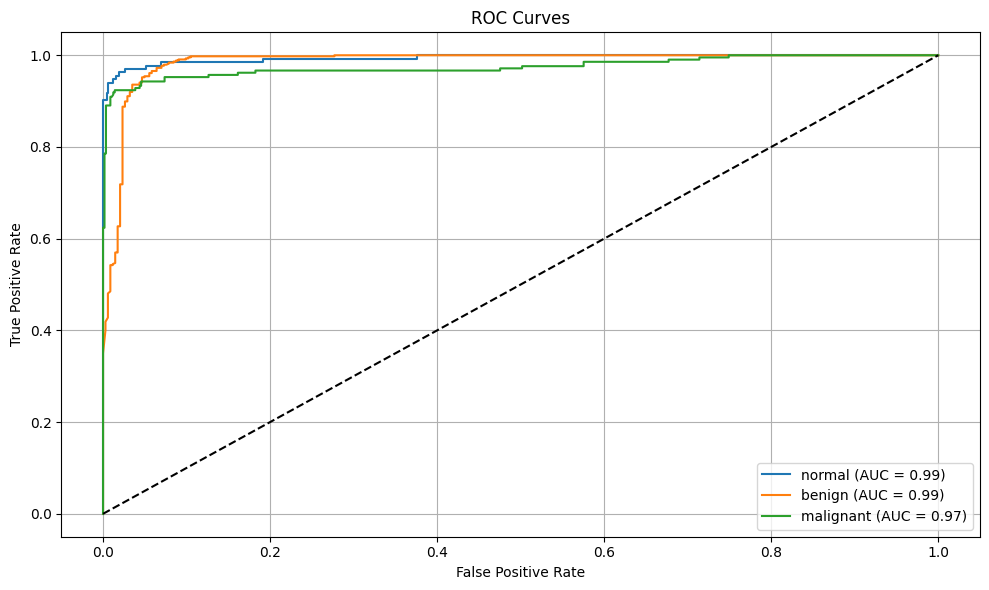

In [16]:
evaluate_model()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
Predicted Class: normal


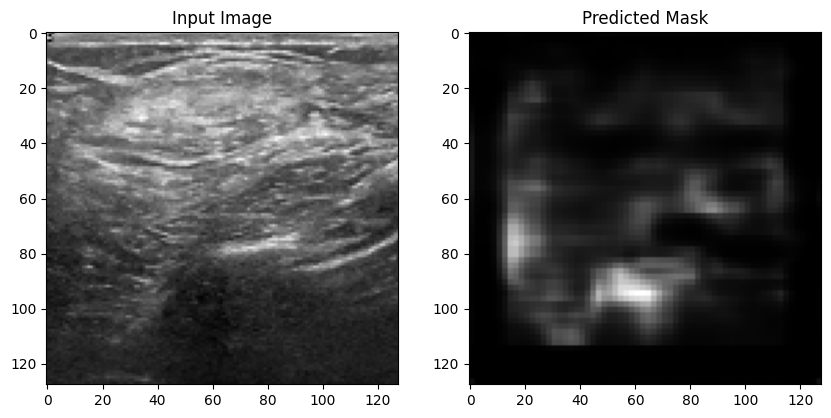

In [14]:
predict("data/normal/normal (2).png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
Predicted Class: benign


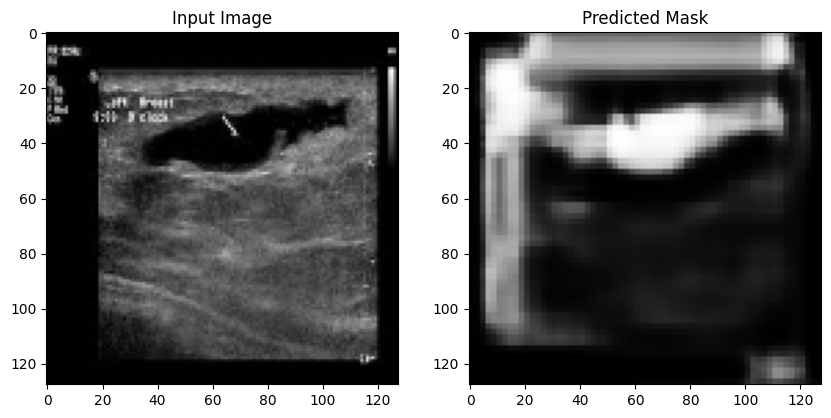

In [18]:
predict("image.png")